# **RICARDO PADILLA HERRERA**

# NATURAL LENGUAGE PROCESS - ASSIGNMENT 2
---


# HOW BUDGET INFLUENCES HORROR NARRATIVES? A TEXT MINING STUDY OF HORROR MOVIE NARRATIVES

This project examines whether the budget of a film is associated with differences in how horror stories are described. While horror movies share common themes, production resources may influence settings, characters, and the scale of the threat.

Using Natural Language Processing (NLP), movie plot descriptions are cleaned and divided into low-budget and high-budget groups. Word frequency analysis and word clouds are used to observe common vocabulary, while TF-IDF identifies words that distinguish each group.

The goal is to understand if investment level is related to different narrative patterns in horror films.

## SET UP


In [1]:
#@title Setup (click the "run" button to the left) {display-mode: "form"}

## Setup ##

# imports

# built-in Python libraries
# -------------------------

# counting and data management
import collections
# operating system utils
import os
# regular expressions
import re
# additional string functions
import string
# system utilities
import sys
# request() will be used to load web content
import urllib.request


# 3rd party libraries
# -------------------

# Natural Language Toolkit (https://www.nltk.org/)
import nltk

# download punctuation related NLTK functions
# (needed for sent_tokenize())
nltk.download('punkt')
nltk.download('punkt_tab')
# download NLKT part-of-speech tagger
# (needed for pos_tag())
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
# download wordnet
# (needed for lemmatization)
nltk.download('wordnet')
# download stopword lists
# (needed for stopword removal)
nltk.download('stopwords')
# dictionary of English words
nltk.download('words')
nltk.download('omw-1.4')

# numpy: matrix library for Python
import numpy as np

# scipy: scientific operations
# works with numpy objects
import scipy

# matplotlib (and pyplot) for visualizations
import matplotlib
import matplotlib.pyplot as plt

# sklearn for basic machine learning operations
import sklearn
import sklearn.manifold
import sklearn.cluster

# worldcloud tool
!pip install wordcloud
from wordcloud import WordCloud

# for checking object memory usage
!pip install pympler
from pympler import asizeof

!pip install spacy
import spacy

print()
print("Done with setup!")
print("If you'd like, you can click the (X) button to the left to clear this output.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package omw-1.4 t


Done with setup!
If you'd like, you can click the (X) button to the left to clear this output.


In [2]:
# Import libraries and read dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

True

## DATA LOADING

In [3]:
# DATA ACCESS & REPRODUCIBILITY

!pip -q install gdown

import os
import gdown

file_id = "1EbZeuO5agx1U7bJoJJokgZbYvpXwB9IR"
output = "tmdb_930k_movies.csv"

# download dataset automatically
if not os.path.exists(output):
    print("Downloading dataset...")
    gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

print("Dataset ready ✔")

Downloading...
From (original): https://drive.google.com/uc?id=1EbZeuO5agx1U7bJoJJokgZbYvpXwB9IR
From (redirected): https://drive.google.com/uc?id=1EbZeuO5agx1U7bJoJJokgZbYvpXwB9IR&confirm=t&uuid=1541dd1f-1afa-4f96-a0b8-a6408108b68e
To: /content/tmdb_930k_movies.csv
100%|██████████| 609M/609M [00:06<00:00, 96.1MB/s]

Dataset ready ✔


In [4]:
# Loading the dataset

Csv_path = "tmdb_930k_movies.csv"
df_raw = pd.read_csv(Csv_path)

print("Raw shape:", df_raw.shape)
df_raw.head(3)


Raw shape: (1368726, 24)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."


In [5]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## DATA CLEANING

In [6]:
# Keep only relevant columns for this assignment

cols_keep = [
    "title", "genres", "overview", "budget", "tagline", "keywords", "revenue", "release_date"]

df = df_raw[cols_keep].copy()
print("Working shape:", df.shape)
df.head(3)

Working shape: (1368726, 8)


,title,genres,overview,budget,tagline,keywords,revenue,release_date
0,Inception,"Action, Science Fiction, Adventure","Cobb, a skilled thief who commits corporate es...",160000000,Your mind is the scene of the crime.,"rescue, mission, dream, airplane, paris, franc...",825532764,2010-07-15
1,Interstellar,"Adventure, Drama, Science Fiction",The adventures of a group of explorers who mak...,165000000,Mankind was born on Earth. It was never meant ...,"rescue, future, spacecraft, race against time,...",701729206,2014-11-05
2,The Dark Knight,"Drama, Action, Crime, Thriller",Batman raises the stakes in his war on crime. ...,185000000,Welcome to a world without rules.,"joker, sadism, chaos, secret identity, crime f...",1004558444,2008-07-16


In [7]:
# Data type cleaning (dates + numbers)

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1368726 entries, 0 to 1368725
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   title         1368708 non-null  object        
 1   genres        775466 non-null   object        
 2   overview      1058889 non-null  object        
 3   budget        1368726 non-null  int64         
 4   tagline       190589 non-null   object        
 5   keywords      343150 non-null   object        
 6   revenue       1368726 non-null  int64         
 7   release_date  1078454 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 83.5+ MB


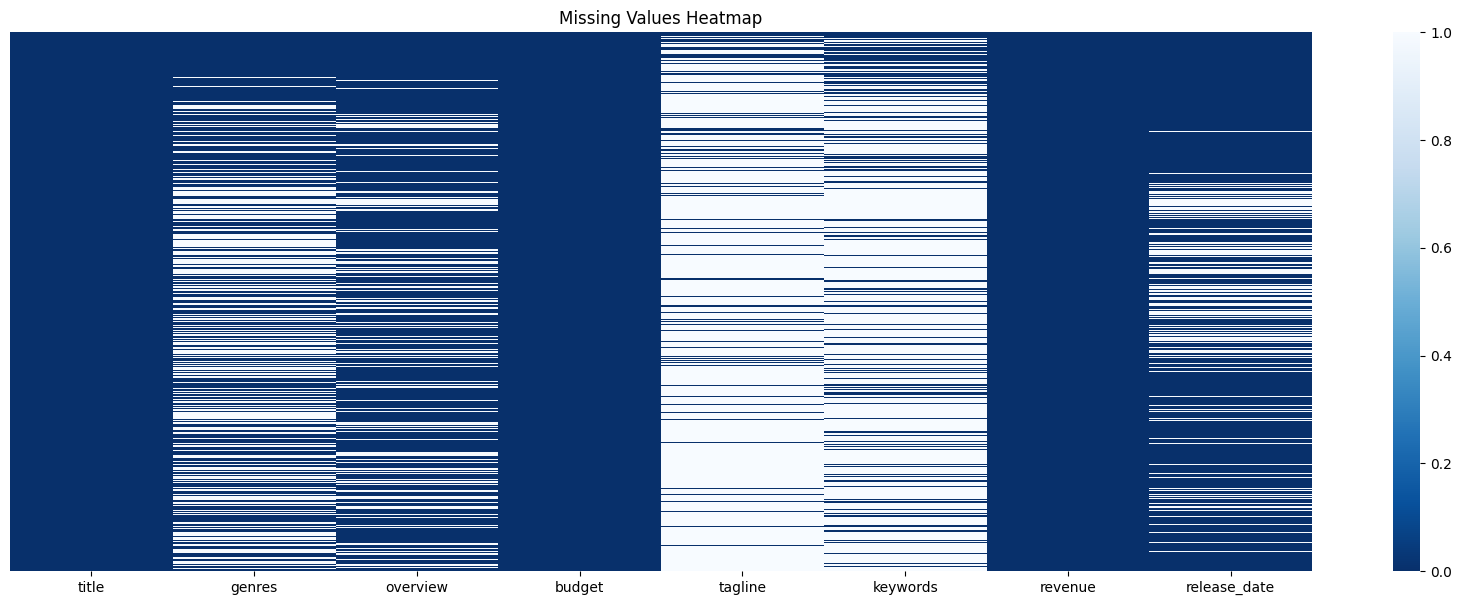

In [8]:
# Missing values Heatmap

plt.figure(figsize=(21,7))

sns.heatmap(
    df.isnull(), cbar=True, yticklabels=False, cmap="Blues_r")

plt.title("Missing Values Heatmap")
plt.show()

In [9]:
# Basic cleaning (keep valid docs)

# keep rows with essential fields
df = df.dropna(subset=["overview", "genres", "budget"]).copy()

# remove empty/too-short descriptions
df["overview"] = df["overview"].astype(str)
df = df[df["overview"].str.len() > 10].copy()

# remove invalid budgets
df = df[df["budget"] > 0].copy()

print("After cleaning:", df.shape)

After cleaning: (52116, 8)


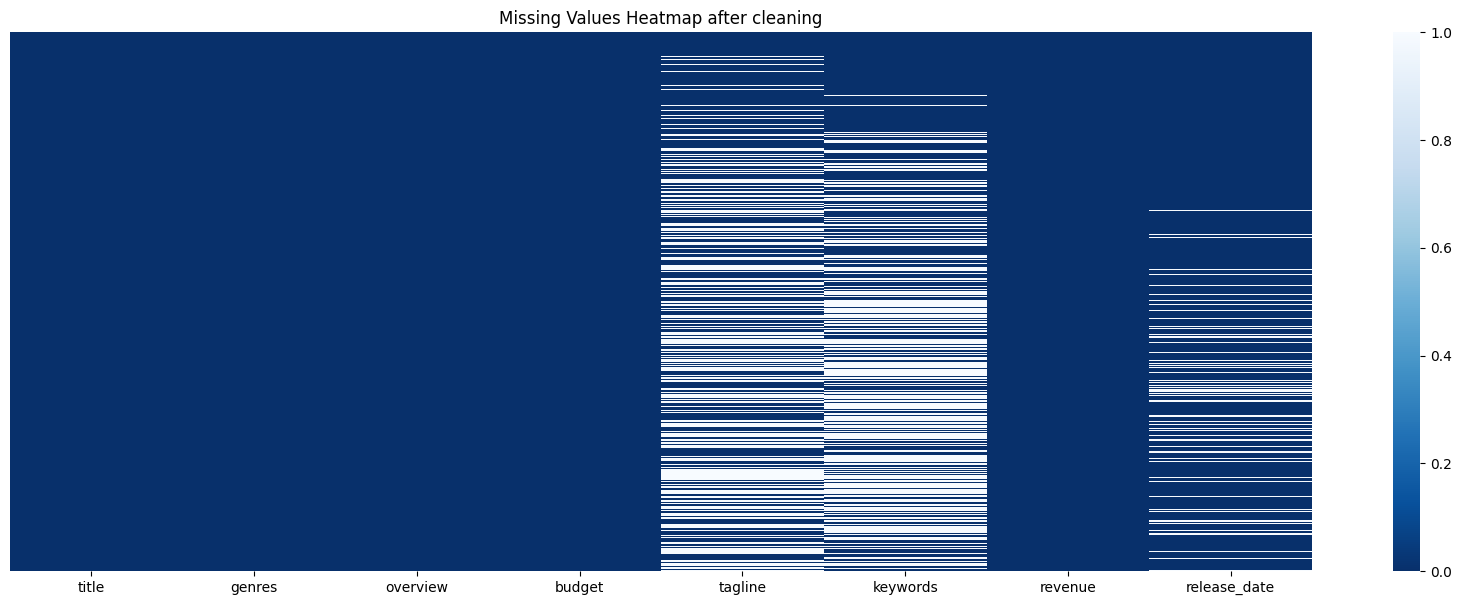

In [10]:
# Heatmap to create check the null values

plt.figure(figsize=(21,7))

sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="Blues_r")

plt.title("Missing Values Heatmap after cleaning")
plt.show()

## TEXT PREPROCESSING


In [11]:
#Text Preprocessing pipeline

stop_words = set(stopwords.words("english"))
extra_stop = {
    "film","movie","story","life","lives","one","two","year","years",
    "man","woman","girl","boy","young","new","time","family","finds"}

lemmatizer = WordNetLemmatizer()

def preprocess(text: str):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and t not in extra_stop and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tagged = pos_tag(tokens)

    tokens = [w for w, pos in tagged if pos.startswith("NN") or pos.startswith("JJ")]

#if POS filtering removed everything, keep lemmatized words
    if len(tokens) == 0:
        clean_tokens = [lemmatizer.lemmatize(w) for w, _ in tagged]

    return tokens

# Create a new column with the clean overview. This is reutilizable for future analysis

df["clean_overview"] = df["overview"].fillna("").apply(preprocess)
df[["title", "clean_overview"]].head(3)

,title,clean_overview
0,Inception,"[cobb, thief, commits, corporate, espionage, s..."
1,Interstellar,"[adventure, group, use, wormhole, surpass, lim..."
2,The Dark Knight,"[batman, stake, war, crime, help, gordon, dist..."


## FILTERING: HORROR MOVIES (RELEASED AFTER 1975) BY BUDGET LEVEL

In [12]:
# Selecting the horror genre to make the comparation

# Keep only movies whose genres contain the target word
Target_genre = "Horror"

df["genres_clean"] = df["genres"].astype(str).str.lower()
target = Target_genre.lower()

# Keep only movies whose genres contain the target word
df_genre = df[df["genres_clean"].str.contains(rf"\b{target}\b", regex=True)].copy()

print("Genre movies before placeholders cleaning:", df_genre.shape)

# Remove placeholder budgets
df_genre = df_genre[df_genre["budget"] >= 10000].copy()

print("Genre movies after placeholders cleaning:", df_genre.shape)
df_genre["budget"].describe()

# Keep movies after 1975 (start of blockbuster era and improve the comparability )
df_genre["release_date"] = pd.to_datetime(df_genre["release_date"], errors="coerce")

print("Before year filter:", df_genre.shape)
df_genre = df_genre[df_genre["release_date"].dt.year >= 1975].copy()

print("After year filter:", df_genre.shape)

Genre movies before placeholders cleaning: (9944, 10)
Genre movies after placeholders cleaning: (4448, 10)
Before year filter: (4448, 10)
After year filter: (3952, 10)


In [13]:
# Spliting movies by budget. We divide movies into two groups based on production investment

low_q  = df_genre["budget"].quantile(0.20)
high_q = df_genre["budget"].quantile(0.80)

low_df  = df_genre[df_genre["budget"] <= low_q].copy()
high_df = df_genre[df_genre["budget"] >= high_q].copy()

print("Low docs:", len(low_df),  " budget <=", round(low_q,2))
print("High docs:", len(high_df), " budget >=", round(high_q,2))

Low docs: 804  budget <= 25000.0
High docs: 845  budget >= 5000000.0


In [14]:
# Example movie´s titles from Low budget (after filters)

low_df[["title","budget","genres","release_date"]].head(10).sort_values("budget", ascending=True)

,title,budget,genres,release_date
8981,Birdemic: Shock and Terror,10000,"Thriller, Fantasy, Romance, Horror, Science Fi...",2010-02-27
9735,The Deaths of Ian Stone,10000,"Horror, Thriller",2007-12-05
12749,Benny Loves You,10000,"Horror, Comedy",2019-11-21
14837,Shark Side of the Moon,10000,"Action, Science Fiction, Thriller, Horror",2022-08-12
16241,Dracula 3000,10000,"Horror, Science Fiction",2004-08-09
14258,Skinamarink,15000,"Horror, Mystery",2023-01-13
7592,Cure,20000,"Crime, Thriller, Horror, Mystery",1997-12-27
18804,Surf Nazis Must Die,20000,"Action, Comedy, Horror",1987-07-03
22274,P,20000,"Horror, Drama",2005-10-07
19408,Hollywood Chainsaw Hookers,23000,"Comedy, Horror",1988-03-01


In [15]:
# Example movie´s titles from High budget (after filters)

high_df[["title","budget","genres","release_date"]].head(10).sort_values("budget", ascending=False)

,title,budget,genres,release_date
126,World War Z,200000000,"Action, Drama, Horror, Science Fiction, Thriller",2013-06-20
62,It,40000000,"Horror, Fantasy",2017-09-06
207,Zombieland,23600000,"Comedy, Horror",2009-10-07
86,The Shining,19000000,"Horror, Thriller",1980-05-23
155,A Quiet Place,17000000,"Horror, Drama, Science Fiction",2018-04-03
238,The Conjuring,13000000,"Horror, Thriller",2013-07-18
142,Black Swan,13000000,"Drama, Thriller, Horror",2010-12-03
150,Alien,11000000,"Horror, Science Fiction",1979-05-25
84,Split,9000000,"Horror, Thriller",2017-01-19
303,Jaws,7000000,"Horror, Thriller, Adventure",1975-06-20


## DOCUMENT VECTORIZATION

In [16]:
# Document vectorization

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

token_col = "clean_overview" if "clean_overview" in low_df.columns else "clean_tokens"

low_df["clean_text"]  = low_df[token_col].apply(lambda toks: " ".join(toks))
high_df["clean_text"] = high_df[token_col].apply(lambda toks: " ".join(toks))

# Combine both groups so they share the SAME vocabulary
combined_text = pd.concat([low_df["clean_text"], high_df["clean_text"]], ignore_index=True)

vectorizer = CountVectorizer(
    min_df=5,        # removes very rare words (noise)
    max_df=0.85      # removes extremely common words
)

X = vectorizer.fit_transform(combined_text)
vocab = vectorizer.get_feature_names_out()

print("Number of documents:", X.shape[0])
print("Vocabulary size:", X.shape[1])
print("Non-zero elements:", X.nnz)
print("Matrix sparsity:", 1 - X.nnz/(X.shape[0]*X.shape[1]))

Number of documents: 1649
Vocabulary size: 1151
Non-zero elements: 17252
Matrix sparsity: 0.9909104272446929


The movie overviews were transformed into a numerical format using a Bag-of-Words model, where each document is represented by a vector counting the occurrences of each term. After preprocessing and removing both rare and overly frequent words, the final vocabulary consisted of 1,151 unique terms across 1,649 movies. As expected in textual data, the document-term matrix is highly sparse (around 99%), since each movie description contains only a small portion of the overall vocabulary. This representation enables quantitative comparison between films and supports subsequent analyses such as term frequency comparisons and TF-IDF weighting.

## FREQUENCY OF WORDS

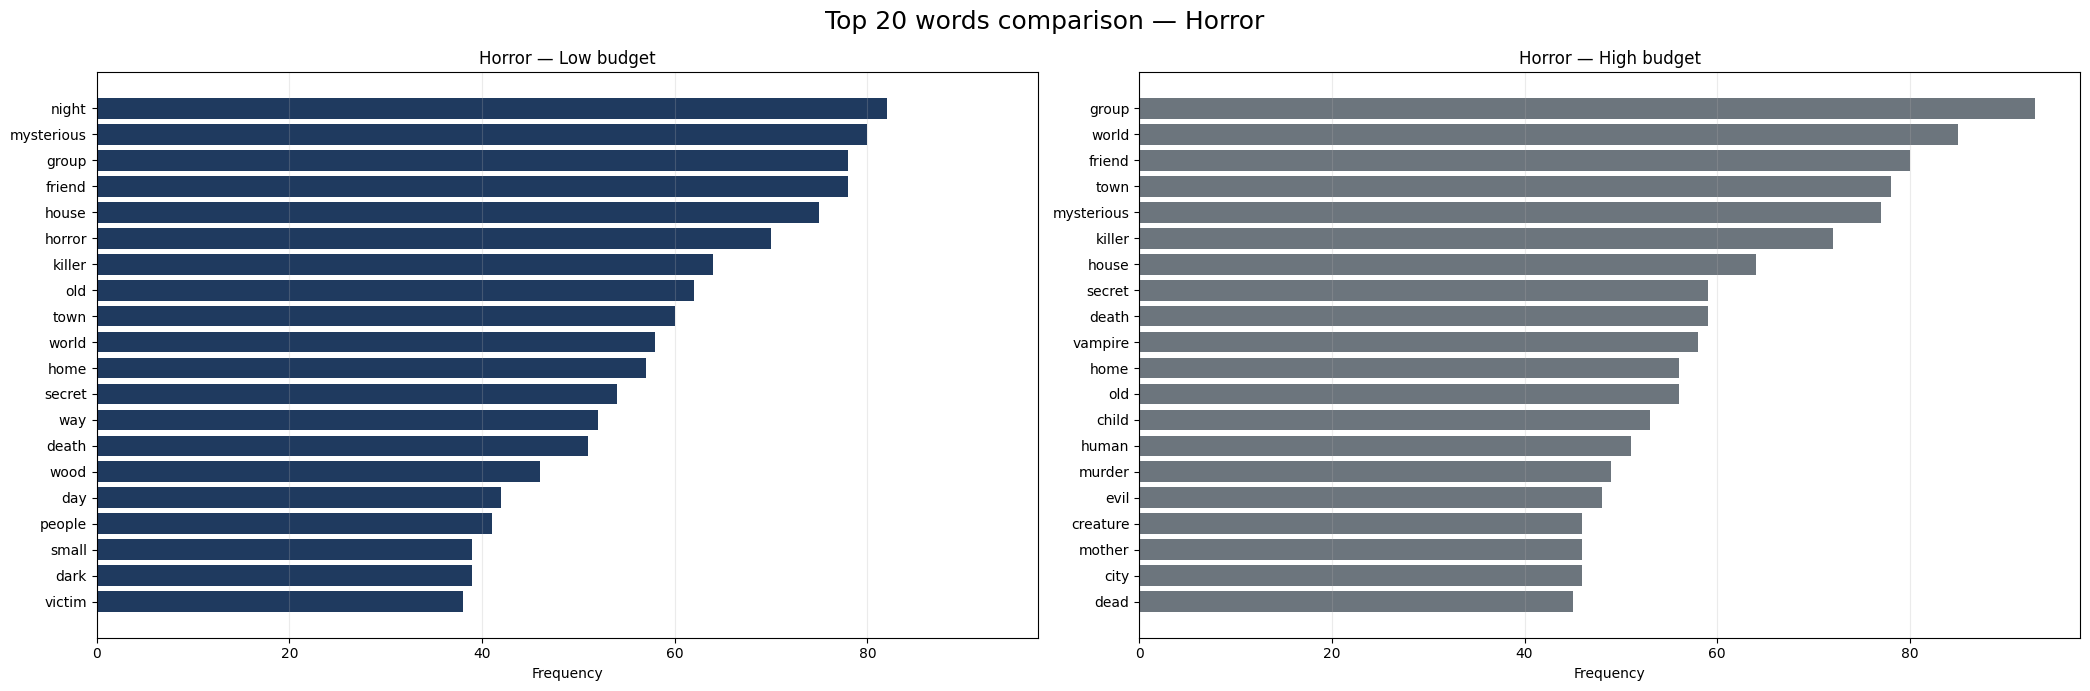

In [17]:
# Graph thr frequency of words

from collections import Counter

# Flatten token lists
low_tokens  = [word for tokens in low_df[token_col] for word in tokens]
high_tokens = [word for tokens in high_df[token_col] for word in tokens]

# Frequency counters
low_freq = Counter(low_tokens)
high_freq = Counter(high_tokens)

def compare_top_words(counter_low, counter_high, genre, n=20):

    # Top words
    low_top  = counter_low.most_common(n)
    high_top = counter_high.most_common(n)

    low_words  = [w for w, c in low_top]
    low_counts = [c for w, c in low_top]

    high_words  = [w for w, c in high_top]
    high_counts = [c for w, c in high_top]

    # Figure
    fig, axes = plt.subplots(1, 2, figsize=(21, 7), sharex=True)

    # LOW budget (left)
    axes[0].barh(low_words, low_counts, color="#1F3A5F")
    axes[0].set_title(f"{genre} — Low budget", fontsize=12)
    axes[0].set_xlabel("Frequency")
    axes[0].invert_yaxis()
    axes[0].grid(axis="x", alpha=0.25)

    # HIGH budget (right)
    axes[1].barh(high_words, high_counts, color="#6C757D")
    axes[1].set_title(f"{genre} — High budget", fontsize=12)
    axes[1].set_xlabel("Frequency")
    axes[1].invert_yaxis()
    axes[1].grid(axis="x", alpha=0.25)

    plt.suptitle(f"Top {n} words comparison — {genre}", fontsize=18)
    plt.tight_layout()
    plt.show()

compare_top_words(low_freq, high_freq, Target_genre)

Horror films show a very similar vocabulary across budgets, with frequent terms such as house, night, death, killer, family, and mysterious appearing in both low- and high-budget productions. This indicates the genre relies on familiar narrative conventions, where the main difference is scale rather than concept (e.g., a simple home versus a mansion). Recurring references to locations, nighttime settings, and threats quickly communicate danger and suspense, while family-related words (mother, child, son) highlight emotional vulnerability to intensify fear. Some variations also emerge: day-related terms appear more often in low-budget films, likely due to practical production constraints, suggesting the vocabulary reflects both storytelling choices and filmmaking limitations.

## WORD CLOUD

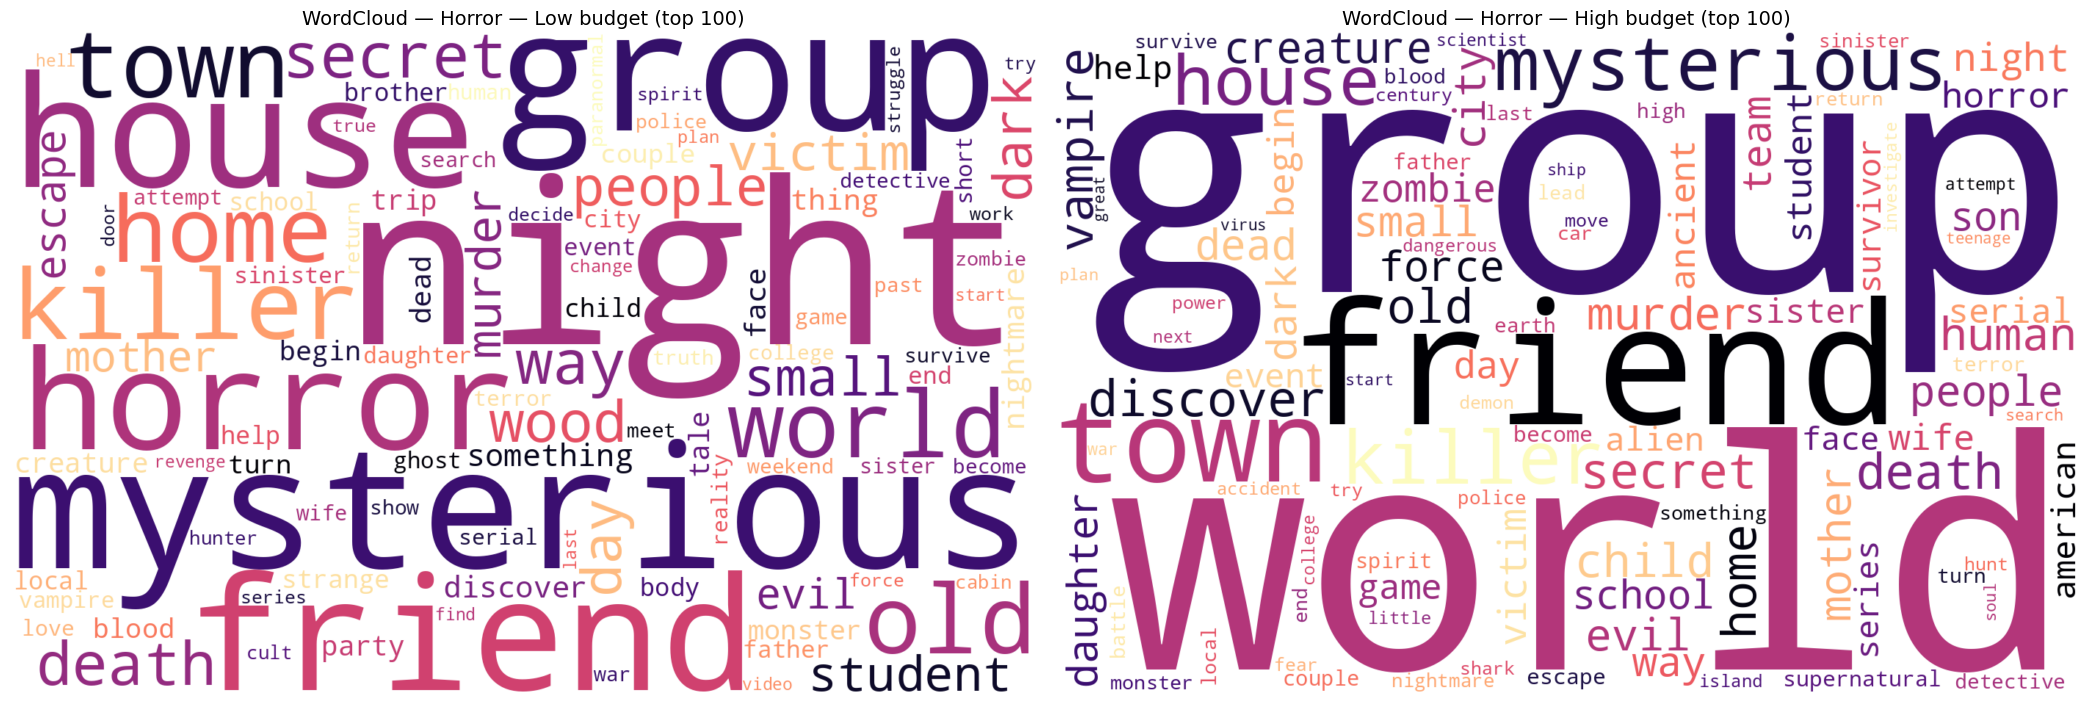

In [18]:
# Create two word clouds (top 100 words)

import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Ensure we have token lists
token_col = "clean_overview" if "clean_overview" in low_df.columns else "clean_tokens"

low_text  = " ".join([w for tokens in low_df[token_col] for w in tokens])
high_text = " ".join([w for tokens in high_df[token_col] for w in tokens])

MAX_WORDS = 100
FIG_W, FIG_H = 21, 7
WC_W, WC_H = 1400, 900

# Build wordclouds
wc_low = WordCloud(
    width=WC_W, height=WC_H,
    background_color="white",
    max_words=MAX_WORDS,
    collocations=False,
    colormap="magma"
).generate(low_text)

wc_high = WordCloud(
    width=WC_W, height=WC_H,
    background_color="white",
    max_words=MAX_WORDS,
    collocations=False,
    colormap="magma"
).generate(high_text)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

axes[0].imshow(wc_low, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title(f"WordCloud — {Target_genre} — Low budget (top {MAX_WORDS})", fontsize=14)

axes[1].imshow(wc_high, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title(f"WordCloud — {Target_genre} — High budget (top {MAX_WORDS})", fontsize=14)

plt.tight_layout()
plt.show()


Both low- and high-budget horror films share core genre vocabulary, but their emphasis differs: low-budget movies highlight words such as house, night, killer, secret, and old, suggesting intimate settings and reliance on suspense and atmosphere, often linked to abandoned places or past events. High-budget films instead feature terms like world, city, team, creature, human, and battle, indicating larger narrative scales, multiple characters, and threats beyond a single killer, including supernatural or large-scale dangers. Overall, the results suggest budget shapes portrayal—low-budget horror focuses on isolation and psychological fear, whereas high-budget productions emphasize broader conflicts—while both still follow common genre conventions reflected in shared terms like friends and group

## TF-IDF (TERM FREQUENCY - INVERSE DOCUMENT FREQUENCY)

In [19]:
# TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

def join_tokens(tokens):
    return " ".join(tokens)

low_texts  = low_df["clean_overview"].apply(join_tokens)
high_texts = high_df["clean_overview"].apply(join_tokens)

all_texts = pd.concat([low_texts, high_texts])
labels = ["LOW"]*len(low_texts) + ["HIGH"]*len(high_texts)

vectorizer = TfidfVectorizer(max_features=2000, min_df=5)
X = vectorizer.fit_transform(all_texts)

feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(X.toarray(), columns=feature_names)
tfidf_df["group"] = labels

In [20]:
# Average TF-IDF per group (by budget)

low_mean = tfidf_df[tfidf_df.group == "LOW"].drop(columns=["group"]).mean()
high_mean = tfidf_df[tfidf_df.group == "HIGH"].drop(columns=["group"]).mean()

diff = (high_mean - low_mean).sort_values(ascending=False)

print("\nTop High-budget words (TF-IDF diff):")
print(diff.head(20))

print("\nTop Low-budget words (TF-IDF diff):")
print(diff.tail(20))


Top High-budget words (TF-IDF diff):
vampire     0.008850
son         0.008742
ancient     0.006897
alien       0.006816
york        0.005813
human       0.005761
team        0.005725
island      0.005669
earth       0.005522
survivor    0.005519
target      0.005427
century     0.005307
american    0.005239
accident    0.005223
ship        0.005151
shark       0.005130
virus       0.005082
force       0.005076
doll        0.005066
discover    0.005027
dtype: float64

Top Low-budget words (TF-IDF diff):
character     -0.003823
documentary   -0.003939
past          -0.003958
filmmaker     -0.004025
weekend       -0.004124
film          -0.004384
babysitter    -0.004418
indian        -0.004617
paranormal    -0.004781
show          -0.005242
nightmare     -0.005340
cult          -0.005647
thing         -0.005919
tale          -0.005953
trip          -0.006581
party         -0.007918
wood          -0.009875
short         -0.010630
night         -0.012920
horror        -0.014230
dtype: flo

Unlike frequency counts and word clouds, TF-IDF highlights words that are distinctive to each group rather than simply the most common. High-budget horror films feature terms such as vampire, alien, ancient, human, team, island, earth, and survivor, pointing to larger-scale narratives, broader settings, and threats affecting many people, often requiring special effects. In contrast, low-budget films show words like nightmare, cult, babysitter, trip, party, wood, and weekend, reflecting everyday situations and smaller, relatable environments where fear relies more on tension and atmosphere. Overall, TF-IDF suggests that budget shapes storytelling style: high-budget horror emphasizes external, large-scale dangers, while low-budget horror focuses on personal and psychologically grounded experiences.

## BIGRAM

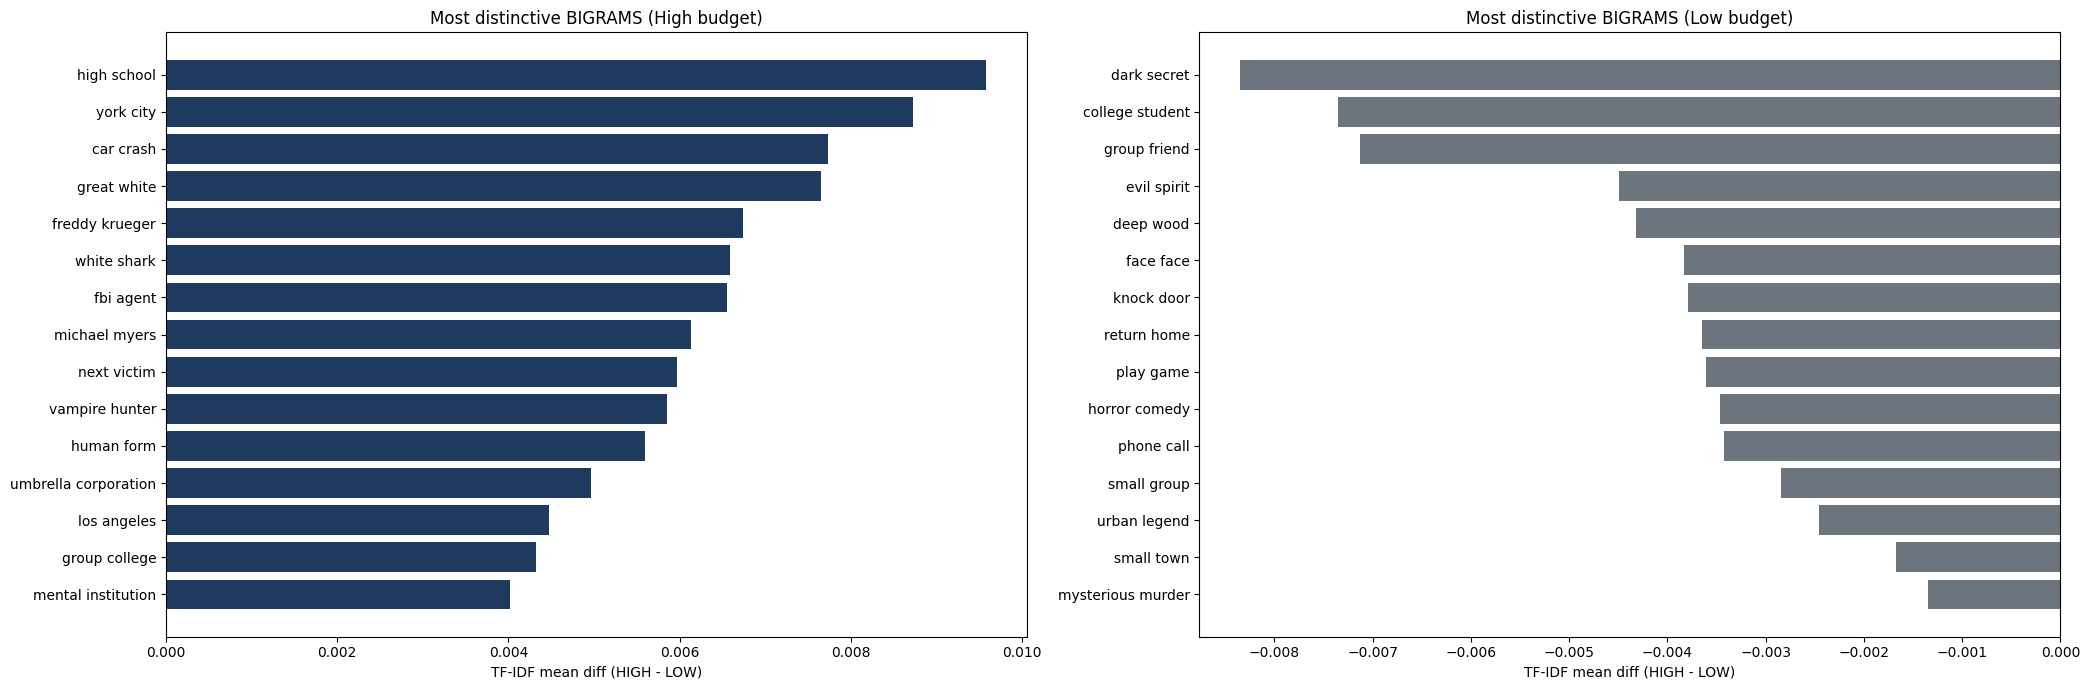

In [21]:
# Creation a BIGRAM

from sklearn.feature_extraction.text import TfidfVectorizer

token_col = "clean_overview" if "clean_overview" in low_df.columns else "clean_tokens"

low_texts  = low_df[token_col].apply(lambda toks: " ".join(toks))
high_texts = high_df[token_col].apply(lambda toks: " ".join(toks))

all_texts = pd.concat([low_texts, high_texts], ignore_index=True)
labels = np.array(["LOW"]*len(low_texts) + ["HIGH"]*len(high_texts))

# BIGRAM TF-IDF
vec_bi = TfidfVectorizer(
    ngram_range=(2, 2),
    min_df=5,
    max_df=0.85
)

X_bi = vec_bi.fit_transform(all_texts)
features = np.array(vec_bi.get_feature_names_out())

# Mean TF-IDF per group
low_mean  = X_bi[labels=="LOW"].mean(axis=0).A1
high_mean = X_bi[labels=="HIGH"].mean(axis=0).A1
diff = high_mean - low_mean

# Top distinctive bigrams
top_n = 15
top_high_idx = np.argsort(diff)[-top_n:][::-1]
top_low_idx  = np.argsort(diff)[:top_n]

top_high = pd.DataFrame({"bigram": features[top_high_idx], "diff": diff[top_high_idx]})
top_low  = pd.DataFrame({"bigram": features[top_low_idx],  "diff": diff[top_low_idx]})

# Plot
fig, axes = plt.subplots(1, 2, figsize=(21, 7), sharex=False)

axes[0].barh(top_high["bigram"][::-1], top_high["diff"][::-1], color="#1F3A5F")
axes[0].set_title("Most distinctive BIGRAMS (High budget)")
axes[0].set_xlabel("TF-IDF mean diff (HIGH - LOW)")

axes[1].barh(top_low["bigram"][::-1], top_low["diff"][::-1], color="#6C757D")
axes[1].set_title("Most distinctive BIGRAMS (Low budget)")
axes[1].set_xlabel("TF-IDF mean diff (HIGH - LOW)")

plt.tight_layout()
plt.show()


The bigram TF-IDF analysis highlights expressions that uniquely characterize each budget group. High-budget horror films include bigrams such as york city, los angeles, fbi agent, vampire hunter, and references to iconic characters, suggesting larger-scale narratives, urban settings, and more complex, action-oriented conflicts often supported by higher production investment. In contrast, low-budget films feature terms like dark secret, college student, group friend, deep wood, small town, and phone call, reflecting everyday situations and contained environments where fear is built through isolation and interpersonal tension. Overall, the results confirm that high-budget horror emphasizes spectacle and expansive plots, while low-budget horror relies on familiarity and psychological suspense.

## SENTIMENT ANALYSIS

=== Sentiment (VADER compound) ===
Text column used: overview
LOW  mean: -0.3499 | n=804
HIGH mean: -0.4190 | n=845
Welch t-test: t=2.6507, p=0.008110


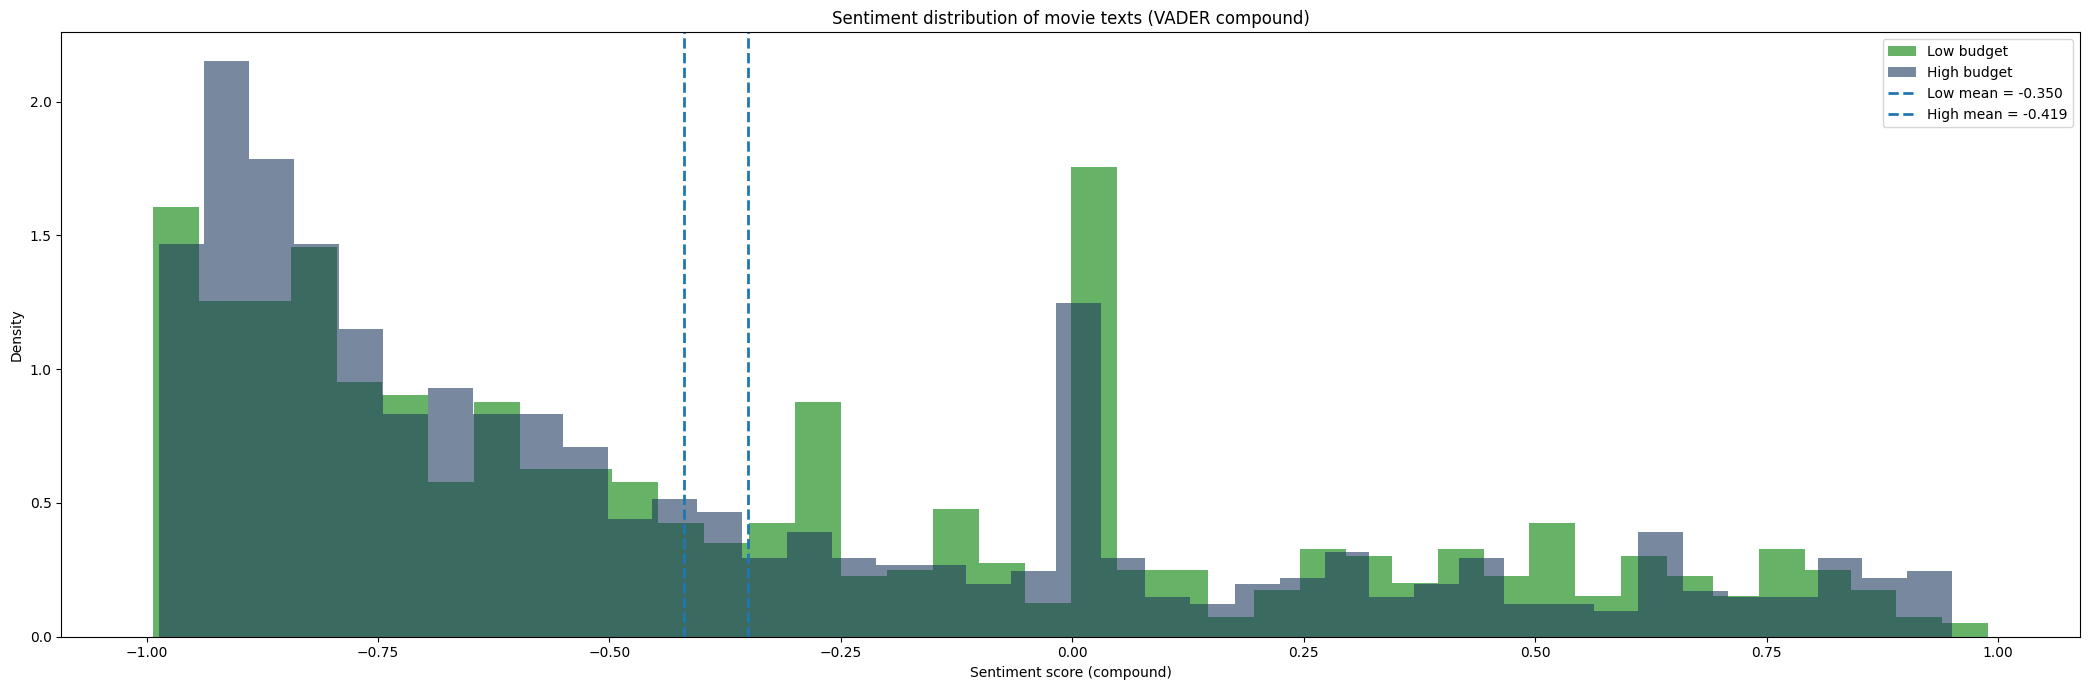

In [22]:

# SENTIMENT ANALYSIS (VADER)

from nltk.sentiment import SentimentIntensityAnalyzer
from scipy.stats import ttest_ind

# 1) Setup
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()

# 2) Choose the text column (prefer original, not cleaned tokens)
# Try common options; adjust if your dataset uses a different name.
CANDIDATE_TEXT_COLS = ["overview", "description", "plot", "synopsis", "clean_text"]
text_col = next((c for c in CANDIDATE_TEXT_COLS if c in low_df.columns and c in high_df.columns), None)
if text_col is None:
    raise KeyError(f"No text column found in low_df/high_df. Tried: {CANDIDATE_TEXT_COLS}")

# 3) Compute sentiment (compound in [-1, 1])
def vader_compound(text: str) -> float:
    return sia.polarity_scores(str(text))["compound"]

low_df = low_df.copy()
high_df = high_df.copy()

low_df[text_col] = low_df[text_col].fillna("")
high_df[text_col] = high_df[text_col].fillna("")

low_df["sentiment"] = low_df[text_col].apply(vader_compound)
high_df["sentiment"] = high_df[text_col].apply(vader_compound)

# 4) Quick summary
low_mean = float(low_df["sentiment"].mean())
high_mean = float(high_df["sentiment"].mean())

print("=== Sentiment (VADER compound) ===")
print(f"Text column used: {text_col}")
print(f"LOW  mean: {low_mean:.4f} | n={len(low_df)}")
print(f"HIGH mean: {high_mean:.4f} | n={len(high_df)}")

# 5) Statistical test (Welch's t-test)
t_stat, p_value = ttest_ind(low_df["sentiment"], high_df["sentiment"], equal_var=False, nan_policy="omit")
print(f"Welch t-test: t={t_stat:.4f}, p={p_value:.6f}")

# 6) Visualization: distribution + mean lines
plt.figure(figsize=(21, 7))
plt.hist(low_df["sentiment"].dropna(), bins=40, alpha=0.6, density=True,  color="green", label="Low budget")
plt.hist(high_df["sentiment"].dropna(), bins=40, alpha=0.6, density=True, color="#1F3A5F", label="High budget")

plt.axvline(low_mean, linestyle="--", linewidth=2, label=f"Low mean = {low_mean:.3f}")
plt.axvline(high_mean, linestyle="--", linewidth=2, label=f"High mean = {high_mean:.3f}")

plt.title("Sentiment distribution of movie texts (VADER compound)")
plt.xlabel("Sentiment score (compound)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


The VADER sentiment analysis shows that both low- and high-budget horror movie descriptions are predominantly negative, which is consistent with the genre’s focus on danger, fear, and threatening situations. However, high-budget films present a slightly more negative average sentiment (around −0.419) compared to low-budget films (around −0.350), and the difference is statistically significant (Welch t-test p ≈ 0.008). This suggests that high-budget productions tend to emphasize more intense or severe threats in their narratives, while low-budget films, although still negative overall, include relatively more neutral or mixed descriptions. Overall, the results indicate that budget influences not only narrative scale but also emotional tone, with higher-budget horror portraying darker and more extreme situations.